In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import folium
from branca.colormap import linear
from branca.colormap import LinearColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
import warnings
from scipy import stats
from folium.plugins import HeatMap
import matplotlib.cm as cm
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point  # For plotting maps
import hydroeval as he
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
from scipy.stats import linregress

In [2]:
#Define Functions
# Find nearest index
def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

def add_specific_quantiles(group, quantiles):
    group['Quantile'] = pd.qcut(group['Observed'], quantiles, labels=False)
    return group
    
#assign season to xarray
month_to_season = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}
vectorized_assign_season = np.vectorize(lambda month: month_to_season[month])

def round_to_nearest_day(td):
    total_days = td.total_seconds() / (24 * 3600)
    rounded_days = int(np.round(total_days))
    return rounded_days

def abline(slope, intercept, ax, **kwargs):
    """Plot a line from slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, **kwargs)
    
#Define a function that calculates various metrics of comparison between modelled and observed data
def calculate_model_eval(group):
    # Extract X and y
    X = group['Modelled'].values.reshape(-1, 1)  # Reshape to ensure X is a 2D array
    y = group['Observed'].values

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Calculate R-squared value
    r2 = model.score(X, y)

    # Calculate correlation coefficient R
    corr_matrix = np.corrcoef(X.flatten(), y)
    r = corr_matrix[0, 1]

    # Get predictions
    y_pred = model.predict(X)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    # Calculate normalized RMSE
    nrmse = rmse / (np.max(y) - np.min(y))

    # Get slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_

    # Count number of values
    num_values = len(y)

    return pd.Series({
        'Num_Values': num_values, 
        'R': r, 
        'R2': r2, 
        'RMSE': rmse, 
        'NRMSE': nrmse, 
        'Slope': slope, 
        'Intercept': intercept
    })
    
#Define some other model metrics
def calculate_site_solute_metrics(data):
    # Create an empty DataFrame to store the results
    results_df = pd.DataFrame()

    # Iterate over unique combinations of siteId and Solute
    for (site, var), group in data.groupby(['siteId', 'Variable']):
        # Extract Modelled and Observed data for the current site and solute
        simulations = group['Modelled'].tolist()
        evaluations = group['Observed'].tolist()

        # Calculate NSE and KGE metrics
        nse = he.evaluator(he.nse, simulations, evaluations)
        kge, r, alpha, beta = he.evaluator(he.kge, simulations, evaluations)

        # Create a DataFrame with the results for the current site and solute
        result = pd.DataFrame({
            'siteId': [site],
            'Variable': [var],
            'NSE': [nse[0]],  # Extracting the scalar value from the array
            'KGE': [kge[0]],  # Extracting the scalar value from the array
            #'R': [r],
            #'Alpha': [alpha],
            #'Beta': [beta]
        })

        # Append the result to the results DataFrame
        results_df = pd.concat([results_df, result], ignore_index=True)

    return results_df

#Define some other model metrics
def calculate_site_solute_metrics_monthly(data):
    # Create an empty DataFrame to store the results
    results_df = pd.DataFrame()

    # Iterate over unique combinations of siteId and Solute
    for (site, var), group in data.groupby(['Variable', 'Month']):
        # Extract Modelled and Observed data for the current site and solute
        simulations = group['Modelled'].tolist()
        evaluations = group['Observed'].tolist()

        # Calculate NSE and KGE metrics
        nse = he.evaluator(he.nse, simulations, evaluations)
        kge, r, alpha, beta = he.evaluator(he.kge, simulations, evaluations)

        # Create a DataFrame with the results for the current site and solute
        result = pd.DataFrame({
            'Month': [site],
            'Variable': [var],
            'NSE': [nse[0]],  # Extracting the scalar value from the array
            'KGE': [kge[0]],  # Extracting the scalar value from the array
            #'R': [r],
            #'Alpha': [alpha],
            #'Beta': [beta]
        })

        # Append the result to the results DataFrame
        results_df = pd.concat([results_df, result], ignore_index=True)

    return results_df

#Define some other model metrics
def calculate_site_solute_metrics_site_monthly(data):
    # Create an empty DataFrame to store the results
    results_df = pd.DataFrame()

    # Iterate over unique combinations of siteId, Variable, and Month
    for (site, var, month), group in data.groupby(['siteId', 'Variable', 'Month']):
        # Extract Modelled and Observed data for the current site, solute, and month
        simulations = group['Modelled'].tolist()
        evaluations = group['Observed'].tolist()

        # Calculate NSE and KGE metrics
        nse = he.evaluator(he.nse, simulations, evaluations)
        kge, r, alpha, beta = he.evaluator(he.kge, simulations, evaluations)

        # Create a DataFrame with the results for the current site, solute, and month
        result = pd.DataFrame({
            'siteId': [site],
            'Variable': [var],
            'Month': [month],
            'NSE': [nse[0]],  # Extracting the scalar value from the array
            'KGE': [kge[0]],  # Extracting the scalar value from the array
            #'R': [r],
            #'Alpha': [alpha],
            #'Beta': [beta]
        })

        # Append the result to the results DataFrame
        results_df = pd.concat([results_df, result], ignore_index=True)

    return results_df

def run_statistics(df, df_name):
    # Count the number of unique sites
    site_count = df.groupby(['Variable'])['siteId'].nunique()
    print(f"Unique site count for {df_name}:\n", site_count)
    
    # For each variable, count the number of observations
    obs_count = df.groupby(['Variable'])['Modelled'].count()
    print(f"\nObservation count for {df_name}:\n", obs_count)
    
    # For each variable and site, count the number of observations and then average
    obs_site_count = df.groupby(['Variable', 'siteId'])['Modelled'].count().mean()
    print(f"\nAverage number of observations per site for {df_name}:\n", obs_site_count)

def calculate_cohens_d(modelled, observed):
    # Calculate the mean difference
    mean_diff = np.mean(modelled) - np.mean(observed)
    
    # Calculate the pooled standard deviation
    pooled_std = np.sqrt(((np.std(modelled, ddof=1) ** 2 + np.std(observed, ddof=1) ** 2) / 2))
    
    # Calculate Cohen's d
    cohens_d = mean_diff / pooled_std
    
    return cohens_d

def interpret_cohens_d(d):
    if d < 0.2:
        return "Small effect"
    elif 0.2 <= d < 0.8:
        return "Medium effect"
    else:
        return "Large effect"

In [3]:
#Initial data cleaning for nadp_df (inorganics)

#Read in merged df for model validation calculations (inorganics from NADP and DOC/BC from external data sources)
pathData = '/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/SamplingInt_Timeseries_NADPsites'
os.chdir(pathData)
nadp_df = pd.read_csv('PREC_SO4_NO3_NH4_NH3_Timeseries.SamplingInt_Summed_pairedNADPsites.csv', parse_dates = ['dateOn', 'dateOff', 'dateOnround', 'dateOffround'])

#1. Model reports NO3 as HNO3, so need to correct for the small percentage that is H that observed data does not include
#1.a Model also report SO4 and ammonium bisulfate (mass = 115), so need to correct for the molar mass percentage that is sulfate (97).
nadp_df['Mod_NO3_mgm2'] = nadp_df['Mod_NO3_mgm2'] * 0.984006 
nadp_df['Mod_SO4_mgm2'] = nadp_df['Mod_SO4_mgm2'] * 0.843478

#2. Remove rows where there is no observed rain but the model is predicting rain and calculate percent error in precip
#nadp_df = nadp_df.loc[nadp_df.ppt_mm != 0,]
nadp_df['Precip_Perc_Error'] = ((abs(nadp_df['PREC_tot_mm'] - nadp_df['ppt_mm']))/(nadp_df['PREC_tot_mm']))*100
#nadp_df = nadp_df.dropna(subset = 'Precip_Perc_Error')

#3. Keep only rows where the IntTime variable is greater than 0 days and less than 31 days
nadp_df['IntTime'] = pd.to_timedelta(nadp_df['IntTime'])
nadp_df['IntDays'] = nadp_df['IntTime'].apply(round_to_nearest_day)
nadp_df = nadp_df.loc[((nadp_df['IntDays'] > 0) & (nadp_df['IntDays'] <= 31)),]

#4. Read in ntn chemistry and filters for any flags on SO4, NO3, NH4 or subppt or invalid codes or suspicious valcodes
pathData = '/glade/u/home/demurray/External File Uploads/NADP NTN wet dep data/'
os.chdir(pathData)
ntn_chem = pd.read_csv('NTN-ALL-Weekly 2000_2022.csv', parse_dates = ['dateOn', 'dateOff'])
ntn_val = ntn_chem[['siteId', 'dateOn', 'dateOff','flagNH4','flagNO3','flagSO4','invalcode', 'valcode']]
nadp_df = pd.merge(nadp_df, ntn_val, on = ['siteId', 'dateOn', 'dateOff'], how = 'left')

#Select for rows with no invalid code and only valcode of w, wa, wi, and wd (excldeing trace samples and dry collection period)
nadp_df = nadp_df.loc[nadp_df['invalcode'] == '            '] #keep only the data with no invalid codes
nadp_df = nadp_df.loc[nadp_df['valcode'] !='t ',] #remove data with valid code but are trace 
nadp_df = nadp_df.loc[nadp_df['valcode'] !='d ',] #remove data with valid code but are dry
nadp_df  = nadp_df .loc[nadp_df.flagNH4 != '<',] #removed lab flagged NH4 datapoints 
nadp_df  = nadp_df .loc[nadp_df.flagNO3 != '<',] #removed lab flagged NO3 datapoints 
nadp_df  = nadp_df .loc[nadp_df.flagSO4 != '<',] #removed lab flagged SO4 datapoints 

#Write csv out for cataloging lat/lon and site info here, 
nadp_df_siteinfo = nadp_df[['siteId', 'latitude', 'longitude', 'dateOnround', 'dateOffround', 'SO4_mgm2', 'NO3_mgm2', 'NH4_mgm2']]
nadp_df_siteinfo_long = pd.melt(nadp_df_siteinfo, id_vars = ['siteId',  'latitude', 'longitude', 'dateOnround', 'dateOffround'])
nadp_df_siteinfo_long.dropna(inplace = True)

#variable, siteid, sitename, latitude, longitude, sample size
site_info_all = pd.DataFrame()

for i in nadp_df_siteinfo_long.variable.unique():
    dat_var = nadp_df_siteinfo_long.loc[nadp_df_siteinfo_long.variable == i]
    for j in dat_var.siteId.unique():
        dat_var_site = dat_var.loc[dat_var.siteId == j]
        
        # Construct individual site info as a dictionary
        site_info_ind = {
            'Variable': dat_var_site.variable.unique()[0],
            'siteId': dat_var_site.siteId.unique()[0],
            'latitude': dat_var_site.latitude.unique()[0],
            'longitude': dat_var_site.longitude.unique()[0],
            'Sample_size': dat_var_site.value.count(),
            'Start_date': dat_var_site.dateOnround.min(),
            'Stop_date': dat_var_site.dateOffround.max(),
        }
        
        # Append the site info to the main DataFrame
        site_info_all = pd.concat([site_info_all, pd.DataFrame([site_info_ind])], ignore_index=True)
site_info_all

#read in the ntn and get the site name appended and then write out as csv
sitename = pd.read_csv('/glade/u/home/demurray/External File Uploads/NADP NTN wet dep data/ntn.csv')
sitename = sitename[['siteId','siteName']]

site_info_all = pd.merge(sitename, site_info_all, on = 'siteId')
site_info_all.to_csv('/glade/u/home/demurray/External File Uploads/NADP NTN wet dep data/Site information for Table S1.csv')

#5. Subset relevant columns
nadp_df = nadp_df[[ 'siteId', 'latitude', 'longitude', 'lon', 'dateOnround', 'dateOffround', 'IntDays', 'SamplingInt',
                      'Precip_Perc_Error', 'PREC_tot_mm','Mod_SO4_mgm2', 'Mod_NO3_mgm2', 'Mod_NH4_mgm2', 'Mod_NH4_NH3_mgm2',
                      'ppt_mm', 'SO4_mgm2', 'NO3_mgm2', 'NH4_mgm2']]
nadp_df

,siteId,latitude,longitude,lon,dateOnround,dateOffround,IntDays,SamplingInt,Precip_Perc_Error,PREC_tot_mm,Mod_SO4_mgm2,Mod_NO3_mgm2,Mod_NH4_mgm2,Mod_NH4_NH3_mgm2,ppt_mm,SO4_mgm2,NO3_mgm2,NH4_mgm2
2,AB32,57.1894,-111.6406,248.75,2016-09-29,2016-10-06,7,2.0,24.623204,23.925135,7.455922,11.692332,4.646642,6.255702,18.034,6.888988,3.426460,0.703326
5,AB32,57.1894,-111.6406,248.75,2016-10-19,2016-10-26,7,5.0,59.255854,8.727634,2.252941,6.796658,0.786747,1.412385,3.556,3.940048,6.443472,1.219708
6,AB32,57.1894,-111.6406,248.75,2016-10-26,2016-11-01,6,6.0,51.665379,9.459058,2.002589,7.617239,1.769656,2.098867,4.572,6.391656,9.125712,3.959352
7,AB32,57.1894,-111.6406,248.75,2016-11-01,2016-11-08,7,7.0,23.282551,1.986510,0.355150,0.620891,0.091250,0.133060,1.524,0.890016,0.431292,0.190500
8,AB32,57.1894,-111.6406,248.75,2016-11-08,2016-11-16,8,8.0,93.798886,4.096038,0.264644,1.067471,0.066157,0.133662,0.254,0.141732,0.358902,0.068326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272445,WY99,43.8730,-104.1917,256.25,2022-07-21,2022-07-27,6,1087.0,421.218098,4.629540,2.161137,3.689013,0.177715,1.190684,24.130,15.901670,35.881310,20.486370
272448,WY99,43.8730,-104.1917,256.25,2022-08-12,2022-08-16,4,1090.0,1653.019754,1.767693,4.218309,9.747999,1.484450,4.806368,30.988,6.600444,25.472136,16.051784
272450,WY99,43.8730,-104.1917,256.25,2022-08-26,2022-09-01,6,1092.0,732.675265,0.776173,0.451920,3.692133,0.168920,1.557800,6.463,4.065227,9.688037,5.034677
272453,WY99,43.8730,-104.1917,256.25,2022-09-14,2022-09-21,7,1095.0,257.560282,6.180217,3.092473,10.728949,0.973902,4.348616,22.098,10.032492,24.661368,6.938772


In [4]:
#Initial data cleaning for org_df (organics)
pathData = '/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/SamplingInt_Timeseries_NADPsites'
os.chdir(pathData)
org_df = pd.read_csv('PREC_DOC_BC_Timeseries.SamplingInt_Summed_pairedNADPsites.csv', parse_dates = ['dateOnround', 'dateOffround'])
org_df = org_df.rename(columns = {'Precip_mm' : 'ppt_mm'})

#1. Remove rows where there is no observed rain but the model is predicting rain and calculate percent error in precip
#org_df = org_df.loc[org_df.ppt_mm != 0,]
org_df['Precip_Perc_Error'] = ((abs(org_df['PREC_tot_mm'] - org_df['ppt_mm']))/(org_df['PREC_tot_mm']))*100
#org_df = org_df.dropna(subset = 'Precip_Perc_Error')

#3. Remove rows where the IntTime variable is greater than 0 days and less than 31 days
org_df['IntTime'] = pd.to_timedelta(org_df['IntTime'])
org_df['IntDays'] = org_df['IntTime'].apply(round_to_nearest_day)
org_df = org_df.loc[((org_df['IntDays'] > 0) & (org_df['IntDays'] <= 31)),]

#5. Subset DOC data and format relevant columns
doc_df = org_df.loc[org_df.Variable == 'DOC_mgL',]
doc_df = doc_df.rename(columns = {'Value_mgm2' : 'DOC_mgm2'})
doc_df = doc_df[['siteId', 'latitude', 'longitude', 'lon', 'dateOnround', 'dateOffround', 'IntDays', 'SamplingInt',
                      'Precip_Perc_Error', 'PREC_tot_mm', 'Mod_SOA_POM_BC_mgm2', 
                      'ppt_mm', 'DOC_mgm2']]
doc_df

,siteId,latitude,longitude,lon,dateOnround,dateOffround,IntDays,SamplingInt,Precip_Perc_Error,PREC_tot_mm,Mod_SOA_POM_BC_mgm2,ppt_mm,DOC_mgm2
10,AK02,58.5139,-134.7843,225.0,2017-02-21,2017-02-28,7,0.0,15.082997,7.062729,0.280234,8.128,3.16992
11,AK02,58.5139,-134.7843,225.0,2017-03-21,2017-03-28,7,1.0,41.746441,20.929194,0.386709,12.192,5.97408
12,AK02,58.5139,-134.7843,225.0,2017-04-18,2017-04-25,7,2.0,32.331321,12.011466,0.940074,8.128,4.79552
13,AK02,58.5139,-134.7843,225.0,2017-05-16,2017-05-23,7,3.0,38.797723,63.912654,0.831557,39.116,18.77568
14,AK02,58.5139,-134.7843,225.0,2017-06-13,2017-06-20,7,4.0,48.965870,53.028254,2.240013,78.994,33.96742
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3677,WY08,44.9166,-110.4203,250.0,2018-06-12,2018-06-18,6,7.0,162.293800,15.784590,7.784613,41.402,24.42718
3678,WY08,44.9166,-110.4203,250.0,2018-08-21,2018-08-28,7,8.0,68.173094,9.062092,14.817144,15.240,21.79320
3679,WY08,44.9166,-110.4203,250.0,2018-10-02,2018-10-09,7,9.0,11.923906,15.284511,2.645737,13.462,10.09650
3680,WY08,44.9166,-110.4203,250.0,2018-11-21,2018-11-26,5,10.0,26.627631,12.462457,0.329291,9.144,3.74904


In [5]:
#Create individual dataframes for dropping nans (eg no chemistry was recorded for observed data) 

################# Inorganics
SO4_df = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Mod_SO4_mgm2', 'SO4_mgm2']].dropna()
SO4_df['Variable'] = 'WetDep_SO4_mgm2'
SO4_df = SO4_df.rename(columns = {'Mod_SO4_mgm2':'Modelled', 'SO4_mgm2' : 'Observed'})

NO3_df = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Mod_NO3_mgm2', 'NO3_mgm2']].dropna()
NO3_df['Variable'] = 'WetDep_NO3_mgm2'
NO3_df = NO3_df.rename(columns = {'Mod_NO3_mgm2':'Modelled', 'NO3_mgm2' : 'Observed'})

#Here using the NH3 + NH4 variable as proxy for NH4 in observed samples.
NH4_df = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Mod_NH4_NH3_mgm2', 'NH4_mgm2']].dropna()
NH4_df['Variable'] = 'WetDep_NH4_mgm2'
NH4_df = NH4_df.rename(columns = {'Mod_NH4_NH3_mgm2':'Modelled', 'NH4_mgm2' : 'Observed'})

############### Organics
DOC_df_all = doc_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Mod_SOA_POM_BC_mgm2', 'DOC_mgm2']].dropna()
DOC_df_all['Variable'] = 'WetDep_DOC_mgm2'
DOC_df_all = DOC_df_all.rename(columns = {'Mod_SOA_POM_BC_mgm2':'Modelled', 'DOC_mgm2' : 'Observed'})

#Final df creation
mod_nadp_chem = pd.concat([SO4_df, NO3_df, NH4_df, DOC_df_all]) #, DOC_df_sub, BC_df_all, BC_df_sub])
mod_nadp_chem

,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable
2,AB32,2.0,2016-09-29,2016-10-06,57.1894,248.75,-111.6406,7.455922,6.888988,WetDep_SO4_mgm2
5,AB32,5.0,2016-10-19,2016-10-26,57.1894,248.75,-111.6406,2.252941,3.940048,WetDep_SO4_mgm2
6,AB32,6.0,2016-10-26,2016-11-01,57.1894,248.75,-111.6406,2.002589,6.391656,WetDep_SO4_mgm2
7,AB32,7.0,2016-11-01,2016-11-08,57.1894,248.75,-111.6406,0.355150,0.890016,WetDep_SO4_mgm2
8,AB32,8.0,2016-11-08,2016-11-16,57.1894,248.75,-111.6406,0.264644,0.141732,WetDep_SO4_mgm2
...,...,...,...,...,...,...,...,...,...,...
3677,WY08,7.0,2018-06-12,2018-06-18,44.9166,250.00,-110.4203,7.784613,24.427180,WetDep_DOC_mgm2
3678,WY08,8.0,2018-08-21,2018-08-28,44.9166,250.00,-110.4203,14.817144,21.793200,WetDep_DOC_mgm2
3679,WY08,9.0,2018-10-02,2018-10-09,44.9166,250.00,-110.4203,2.645737,10.096500,WetDep_DOC_mgm2
3680,WY08,10.0,2018-11-21,2018-11-26,44.9166,250.00,-110.4203,0.329291,3.749040,WetDep_DOC_mgm2


In [6]:
#Add precip to this clean chem dataframe

#Precipitation_inorganics
ppt_df_inorg = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'PREC_tot_mm', 'ppt_mm']]
ppt_df_inorg = ppt_df_inorg.rename(columns = {'PREC_tot_mm':'Modelled_precip', 'ppt_mm' : 'Observed_precip'})

#Precipitation organics
ppt_df_org = doc_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'PREC_tot_mm', 'ppt_mm']]
ppt_df_org = ppt_df_org.rename(columns = {'PREC_tot_mm':'Modelled_precip', 'ppt_mm' : 'Observed_precip'})

#Need precip as its own variable in mod_nadp_clean
ppt_df = pd.concat([ppt_df_org, ppt_df_inorg]).drop_duplicates()
ppt_df['Variable'] = 'Precipitation_mm'
ppt_df = ppt_df.rename(columns = {'Modelled_precip':'Modelled', 'Observed_precip' : 'Observed'})
mod_nadp_clean = pd.concat([mod_nadp_chem, ppt_df])

In [7]:
#Calculate percent error between Modeled and Observed and assign precip percent error to each observation
mod_nadp_clean['Percent_Error'] = ((abs(mod_nadp_clean['Modelled'] - mod_nadp_clean['Observed']))/(mod_nadp_clean['Modelled']))*100
mod_nadp_clean

#Assigning precip percent error to all values in df
ppt_qual = pd.concat([ppt_df_org, ppt_df_inorg]).drop_duplicates()
ppt_qual['Precip_Percent_Error'] = ((abs(ppt_qual['Modelled_precip'] - ppt_qual['Observed_precip']))/(ppt_qual['Modelled_precip']))*100
ppt_qual = ppt_qual[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Precip_Percent_Error']]

#Merge with mod_nadp_clean
mod_nadp_clean = pd.merge(mod_nadp_clean, ppt_qual, on = ['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude',
       'lon', 'longitude'])
mod_nadp_clean

,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error
0,AB32,2.0,2016-09-29,2016-10-06,57.1894,248.75,-111.6406,7.455922,6.888988,WetDep_SO4_mgm2,7.603812,24.623204
1,AB32,2.0,2016-09-29,2016-10-06,57.1894,248.75,-111.6406,11.692332,3.426460,WetDep_NO3_mgm2,70.694811,24.623204
2,AB32,2.0,2016-09-29,2016-10-06,57.1894,248.75,-111.6406,6.255702,0.703326,WetDep_NH4_mgm2,88.757040,24.623204
3,AB32,2.0,2016-09-29,2016-10-06,57.1894,248.75,-111.6406,23.925135,18.034000,Precipitation_mm,24.623204,24.623204
4,AB32,5.0,2016-10-19,2016-10-26,57.1894,248.75,-111.6406,2.252941,3.940048,WetDep_SO4_mgm2,74.884648,59.255854
...,...,...,...,...,...,...,...,...,...,...,...,...
713050,WA21,955.0,2018-05-30,2018-06-06,46.8353,237.50,-122.2867,7.936547,1.270000,Precipitation_mm,83.998079,83.998079
713051,WI36,989.0,2018-12-05,2018-12-12,46.0512,270.00,-89.6541,0.393638,1.016000,Precipitation_mm,158.104852,158.104852
713052,WI37,1186.0,2022-11-16,2022-11-23,45.8228,268.75,-91.8744,6.269722,NaN,Precipitation_mm,NaN,NaN
713053,WY08,1011.0,2019-07-10,2019-07-17,44.9166,250.00,-110.4203,16.680388,3.048000,Precipitation_mm,81.727044,81.727044


In [8]:
#Trim dataframe for only including sites within the continental US:
lat_min, lat_max = 24.396308, 49.384358
lon_min, lon_max = -125.000000, -66.934570

# Assuming your DataFrame is named 'df' and has columns 'latitude' and 'longitude'
mod_nadp_clean = mod_nadp_clean[
    (mod_nadp_clean['latitude'] >= lat_min) &
    (mod_nadp_clean['latitude'] <= lat_max) &
    (mod_nadp_clean['longitude'] >= lon_min) &
    (mod_nadp_clean['longitude'] <= lon_max)
]

mod_nadp_clean

,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error
7978,AL02,30.0,2002-01-02,2002-01-09,30.7907,272.50,-87.8498,11.181890,87.04626,WetDep_SO4_mgm2,678.457476,16.545049
7979,AL02,30.0,2002-01-02,2002-01-09,30.7907,272.50,-87.8498,27.295907,51.90336,WetDep_NO3_mgm2,90.150709,16.545049
7980,AL02,30.0,2002-01-02,2002-01-09,30.7907,272.50,-87.8498,1.917561,6.48792,WetDep_NH4_mgm2,238.342332,16.545049
7981,AL02,30.0,2002-01-02,2002-01-09,30.7907,272.50,-87.8498,46.390645,54.06600,Precipitation_mm,16.545049,16.545049
7982,AL02,31.0,2002-01-09,2002-01-16,30.7907,272.50,-87.8498,13.279848,27.40584,WetDep_SO4_mgm2,106.371633,23.911519
...,...,...,...,...,...,...,...,...,...,...,...,...
713050,WA21,955.0,2018-05-30,2018-06-06,46.8353,237.50,-122.2867,7.936547,1.27000,Precipitation_mm,83.998079,83.998079
713051,WI36,989.0,2018-12-05,2018-12-12,46.0512,270.00,-89.6541,0.393638,1.01600,Precipitation_mm,158.104852,158.104852
713052,WI37,1186.0,2022-11-16,2022-11-23,45.8228,268.75,-91.8744,6.269722,NaN,Precipitation_mm,NaN,NaN
713053,WY08,1011.0,2019-07-10,2019-07-17,44.9166,250.00,-110.4203,16.680388,3.04800,Precipitation_mm,81.727044,81.727044


/glade/derecho/scratch/demurray/tmp/ipykernel_17229/1827710696.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_test['Variable'] = pd.Categorical(mod_nadp_clean_test['Variable'], categories=desired_order, ordered=True)


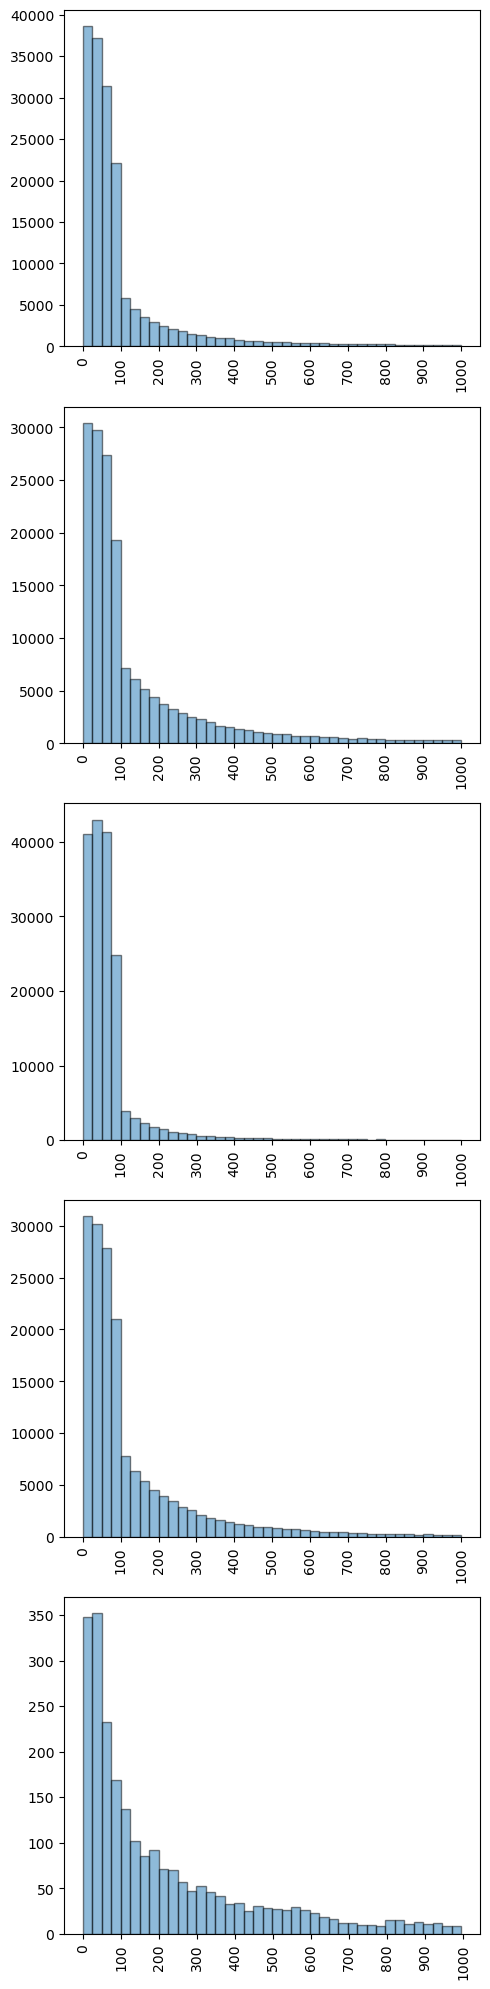

In [9]:
# PLOT: histogram of % error

# Filter the data
mod_nadp_clean = mod_nadp_clean.loc[mod_nadp_clean['Percent_Error'] != np.inf,]
mod_nadp_clean_test = mod_nadp_clean.loc[((mod_nadp_clean['Percent_Error'] < 1000) & (mod_nadp_clean['Percent_Error'] > -100)),]
desired_order = ['Precipitation_mm', 'WetDep_SO4_mgm2', 'WetDep_NO3_mgm2', 'WetDep_NH4_mgm2', 'WetDep_DOC_mgm2']

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_test['Variable'] = pd.Categorical(mod_nadp_clean_test['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_test = mod_nadp_clean_test.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_test['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 5
cols = 1

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(5, 20))
fig.tight_layout(pad=3.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a histogram for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean_test.loc[mod_nadp_clean_test['Variable'] == variable,]
    ax = axs[idx]
    ax.hist(df['Percent_Error'], edgecolor='black', alpha=0.5, bins=40)
    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_title(f'Modelled and Observed |%error|: {variable}')
    ax.set_xticks(np.arange(0, 1001, 100))
    ax.tick_params(axis='x', rotation=90)
    #ax.axvline(x=110, color='red', linestyle=':', linewidth=2.5)
    #ax.axvline(x= 380, color='green', linestyle=':', linewidth=2.5) #line where 90% of data lies

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_test['Variable'].unique()), rows * cols):
    fig.delaxes(axs[idx])

plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Percent Error Histogram.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
plt.show()

In [10]:
#print max %error values
max_perc = mod_nadp_clean.groupby('Variable')['Percent_Error'].max()
max_perc

Variable
Precipitation_mm    2.837760e+16
WetDep_DOC_mgm2     1.591443e+10
WetDep_NH4_mgm2     1.285940e+18
WetDep_NO3_mgm2     1.601660e+18
WetDep_SO4_mgm2     6.626386e+17
Name: Percent_Error, dtype: float64

In [11]:
#calculate total annual average difference between modeled and observed
mod_nadp_clean['year'] = mod_nadp_clean['dateOffround'].dt.year
ann_sum = mod_nadp_clean.groupby(['Variable', 'year'])[['Modelled', 'Observed']].sum().reset_index()
ann_avg_sum = ann_sum.groupby('Variable')[['Modelled', 'Observed']].mean().reset_index()
ann_avg_sum['Modelled'] = ann_avg_sum['Modelled']/1000
ann_avg_sum['Observed'] = ann_avg_sum['Observed']/1000
ann_avg_sum

/glade/derecho/scratch/demurray/tmp/ipykernel_17229/1143112943.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean['year'] = mod_nadp_clean['dateOffround'].dt.year


,Variable,Modelled,Observed
0,Precipitation_mm,164.895575,192.624021
1,WetDep_DOC_mgm2,1.513725,3.619357
2,WetDep_NH4_mgm2,28.273323,49.344322
3,WetDep_NO3_mgm2,150.419171,131.725802
4,WetDep_SO4_mgm2,69.629956,131.707659


In [12]:
#Determine the percent of data that is above the 100% error threshold (aka % of data that we are filtering out)
mod_nadp_clean = mod_nadp_clean.dropna(subset = 'Precip_Percent_Error')

#Total data counts
total_count = mod_nadp_clean.groupby('Variable')['Precip_Percent_Error'].count().reset_index()
total_count['90_perc'] = total_count['Precip_Percent_Error']*0.9
total_count = total_count.rename(columns = {'Precip_Percent_Error' : 'Total_count'})
total_count

# Define the bins
bins = pd.interval_range(start=0, end=1000, freq=25)
bin_labels = [int(interval.left) for interval in bins]
mod_nadp_clean['Error_bin'] = pd.cut(mod_nadp_clean['Precip_Percent_Error'],bins=bins,labels=bin_labels,include_lowest=True)

# Replace NaN values with a placeholder (-1)
mod_nadp_clean['Error_bin_simple'] = mod_nadp_clean['Error_bin'].cat.codes
mod_nadp_clean['Error_bin_simple'] = mod_nadp_clean['Error_bin_simple'].replace(-1, -1).astype(int)

#Group by variable and simple error bin and count
variable_bin_count = mod_nadp_clean.groupby(['Variable', 'Error_bin'])['Precip_Percent_Error'].count().reset_index()
variable_bin_count = variable_bin_count.rename(columns = {'Precip_Percent_Error' : 'Bin_count'})
all_count = pd.merge(variable_bin_count, total_count, on = 'Variable', how = 'left')
all_count.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Bin Precip Percent Error Count.csv')

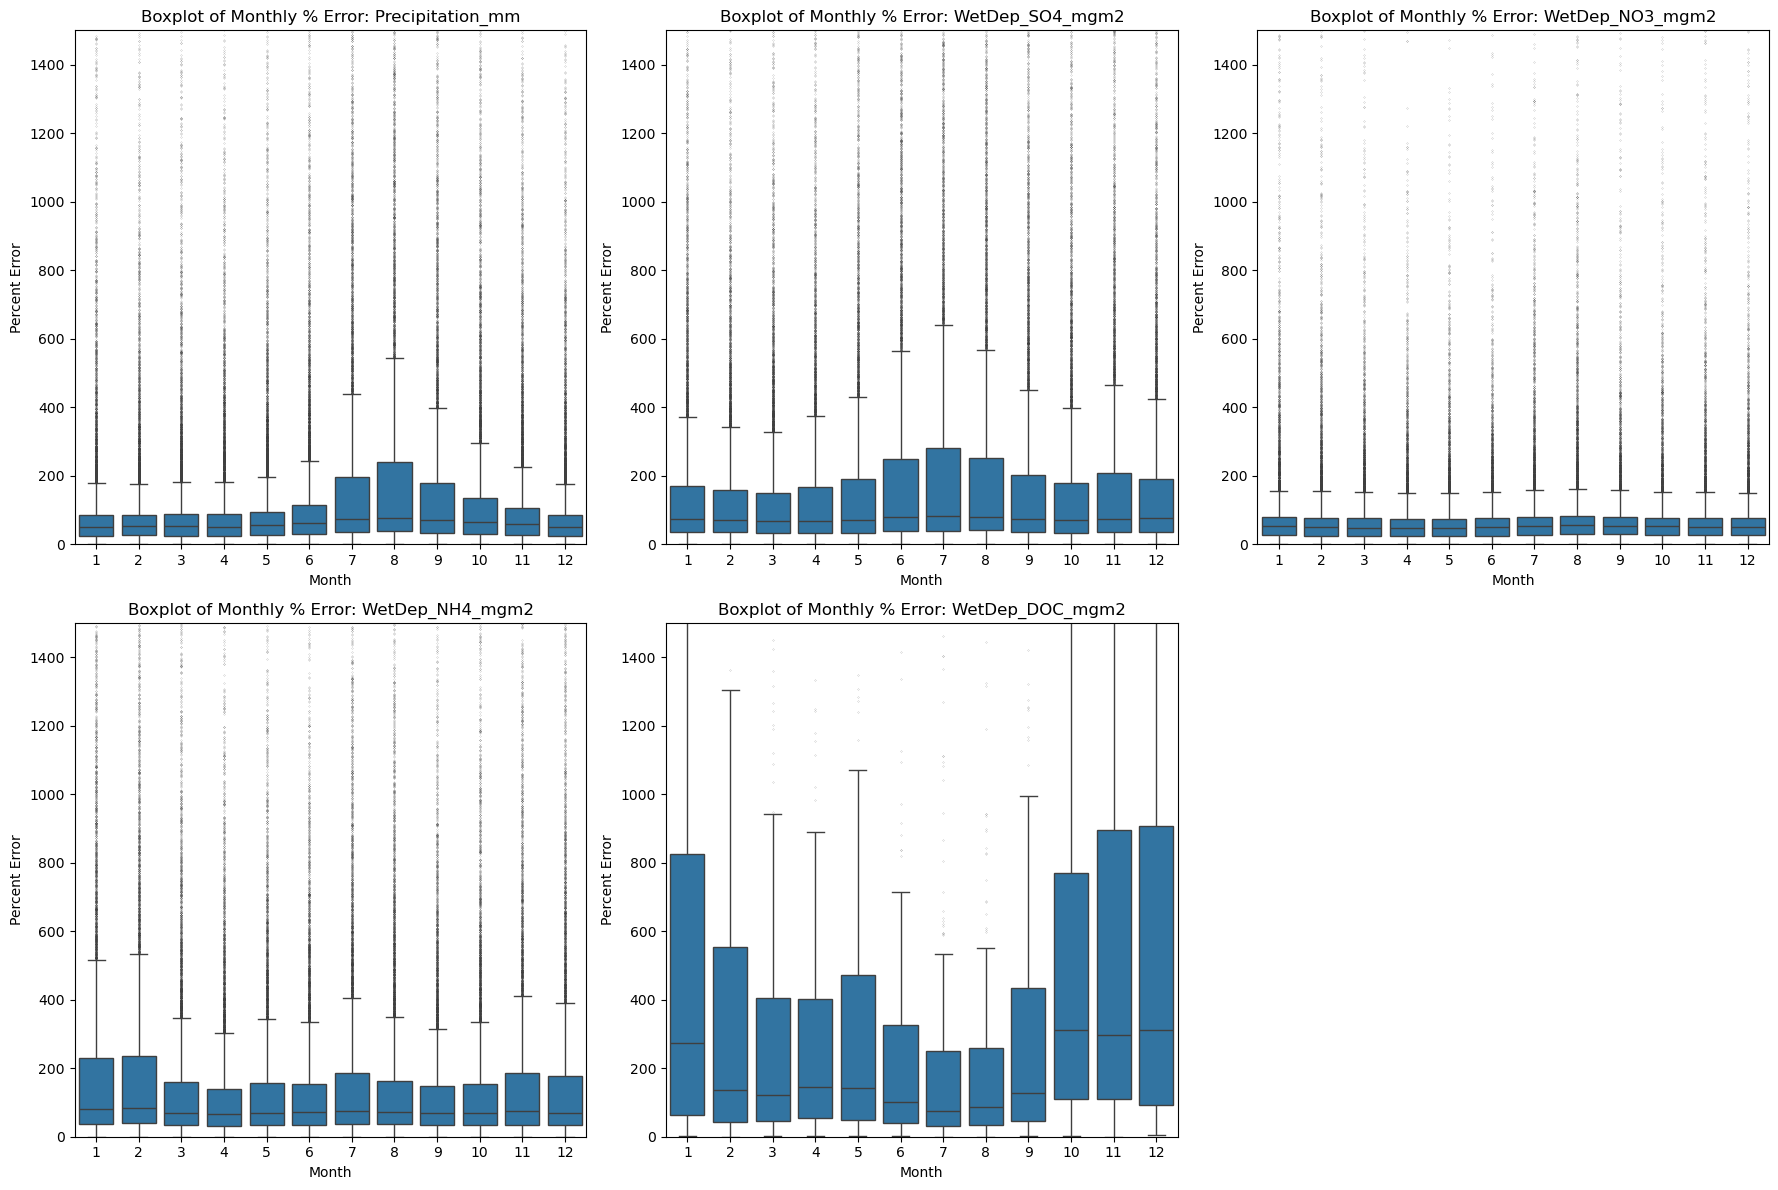

In [13]:
#Plot seasonality of percent error (no filter)
mod_nadp_clean['Month'] = mod_nadp_clean['dateOffround'].dt.month

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean['Variable'] = pd.Categorical(mod_nadp_clean['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean= mod_nadp_clean.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 2
cols = 3

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
fig.tight_layout(pad=5.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a boxplot for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean.loc[mod_nadp_clean['Variable'] == variable,]
    ax = axs[idx]
    sns.boxplot(data=df, x='Month', y='Percent_Error', ax=ax, fliersize=0.1)
    ax.set_ylabel('Percent Error')
    ax.set_ylim(0, 1500)
    ax.set_title(f'Boxplot of Monthly % Error: {variable}')
    #ax.axhline(y=375, color='red', linestyle=':', linewidth=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(variables), rows * cols):
    fig.delaxes(axs[idx])
    
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/No Filter Seasonal Percent Error Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()

In [14]:
# Create a filtered dataframe:

#filter dataframe at 375% precip error tolerance because this is where 
# 90% of the data lies below across all solutes.
mod_nadp_clean_400 = mod_nadp_clean.loc[mod_nadp_clean['Precip_Percent_Error'] < 375,]
print(mod_nadp_clean_400['Precip_Percent_Error'].min())
print(mod_nadp_clean_400['Precip_Percent_Error'].max())

#write this to a csv
mod_nadp_clean_400.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Precip Filtered Cleaned Paired Modeled Observed Timeseries FINAL.csv')

0.0002634445905164123
374.9957071745325


In [15]:
mod_nadp_clean_400.columns

Index(['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude',
       'lon', 'longitude', 'Modelled', 'Observed', 'Variable', 'Percent_Error',
       'Precip_Percent_Error', 'year', 'Error_bin', 'Error_bin_simple',
       'Month'],
      dtype='object')

In [16]:
# group by site and count number of observations
site_obs_precip = mod_nadp_clean_400.groupby(['siteId', 'Variable'])['Modelled'].count().reset_index()
site_obs_precip = site_obs_precip.rename(columns = {'Modelled': 'Precip_filter_count'})
site_obs_precip

site_obs_raw = mod_nadp_clean.groupby(['siteId', 'Variable'])['Modelled'].count().reset_index()
site_obs_raw = site_obs_raw.rename(columns = {'Modelled': 'Raw_count'})

site_obs = pd.merge(site_obs_precip, site_obs_raw, on = ['siteId', 'Variable'], how = 'outer')
site_obs['Difference_count'] = site_obs['Raw_count'] - site_obs['Precip_filter_count']
lat_lon = mod_nadp_clean_400[['siteId', 'latitude', 'longitude']].drop_duplicates()
site_obs_all = pd.merge(site_obs, lat_lon, on = ['siteId'], how = 'left')

site_obs_all.dropna(inplace = True)
site_obs_all = site_obs_all[site_obs_all['Raw_count'] != 0]
site_obs_all

,siteId,Variable,Precip_filter_count,Raw_count,Difference_count,latitude,longitude
0,AL02,Precipitation_mm,226,296,70,30.7907,-87.8498
1,AL02,WetDep_SO4_mgm2,226,296,70,30.7907,-87.8498
2,AL02,WetDep_NO3_mgm2,226,296,70,30.7907,-87.8498
3,AL02,WetDep_NH4_mgm2,226,296,70,30.7907,-87.8498
5,AL03,Precipitation_mm,183,214,31,32.9034,-87.2499
...,...,...,...,...,...,...,...
1578,WY98,WetDep_NH4_mgm2,594,636,42,43.2227,-109.9917
1580,WY99,Precipitation_mm,529,571,42,43.8730,-104.1917
1581,WY99,WetDep_SO4_mgm2,528,570,42,43.8730,-104.1917
1582,WY99,WetDep_NO3_mgm2,528,570,42,43.8730,-104.1917


In [17]:
#plot a map of sites and observation differences
var = 'Difference_count'

var_plot = site_obs_all.loc[site_obs_all.Variable == 'WetDep_DOC_mgm2']
map_center = [var_plot['latitude'].mean(), var_plot['longitude'].mean()]
mymap = folium.Map(location=map_center, zoom_start=4, tiles='CartoDB positron')

# Define Viridis colormap
colormap = linear.viridis.scale(0, var_plot['Difference_count'].max())

# Add points to the map and color them by the value
for i in range(len(var_plot)):
    folium.CircleMarker(
        location=[var_plot.iloc[i]['latitude'], var_plot.iloc[i]['longitude']],
        radius=6,
        color=None,  # Set color to None to remove the outline
        fill=True,
        fill_color=colormap(var_plot.iloc[i][var]),
        fill_opacity=1,
        popup=f'Site ID: {var_plot.iloc[i]["siteId"]}<br>Value: {var_plot.iloc[i][var]}'
    ).add_to(mymap)

# Add legend
colormap.add_to(mymap)

# Display the map
mymap

/glade/derecho/scratch/demurray/tmp/ipykernel_17229/2066076590.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_400['Year'] = mod_nadp_clean_400['dateOffround'].dt.year
/glade/derecho/scratch/demurray/tmp/ipykernel_17229/2066076590.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(


Text(0.5, 1.0, 'Difference in obs/year: before and after precip filter')

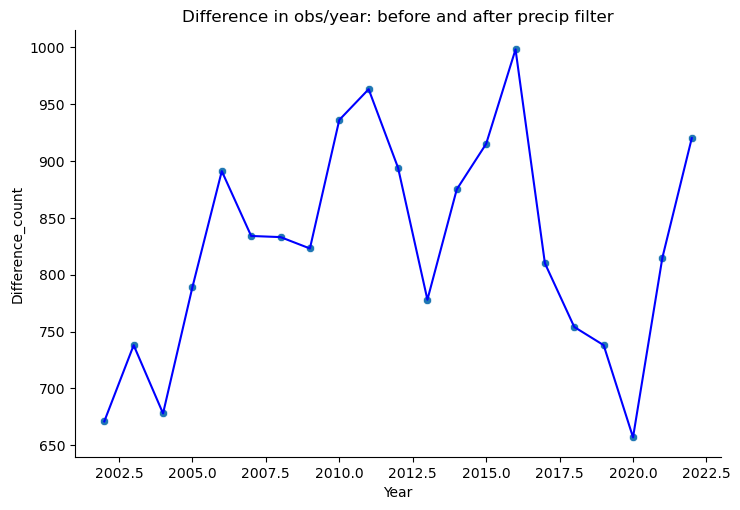

In [18]:
#Do the same thing but over time
mod_nadp_clean_400['Year'] = mod_nadp_clean_400['dateOffround'].dt.year
site_obs_precip = mod_nadp_clean_400.groupby(['Variable', 'Year'])['Modelled'].count().reset_index()
site_obs_precip = site_obs_precip.rename(columns = {'Modelled': 'Precip_filter_count'})
site_obs_precip

mod_nadp_clean['Year'] = mod_nadp_clean['dateOffround'].dt.year
site_obs_raw = mod_nadp_clean.groupby([ 'Variable', 'Year'])['Modelled'].count().reset_index()
site_obs_raw = site_obs_raw.rename(columns = {'Modelled': 'Raw_count'})

site_obs_all = pd.merge(site_obs_precip, site_obs_raw, on = [ 'Variable', 'Year'], how = 'outer')
site_obs_all['Difference_count'] = site_obs_all['Raw_count'] - site_obs_all['Precip_filter_count']

site_obs_all.dropna(inplace = True)
site_obs_all = site_obs_all[site_obs_all['Raw_count'] != 0]
site_obs_all = site_obs_all.loc[site_obs_all.Year < 2023,]

#Plot the difference over time each solute
g = sns.relplot(
    data=site_obs_all.loc[site_obs_all.Variable == 'Precipitation_mm',],
    x="Year", y='Difference_count',  palette= 'viridis',kind='scatter' ,
    height=5, aspect=1.5, facet_kws=dict(sharex=False, sharey = False),
)
sns.lineplot(
    data=site_obs_all.loc[site_obs_all.Variable == 'Precipitation_mm',],
    x="Year", y='Difference_count', color='blue', ax=g.ax
)

plt.title('Difference in obs/year: before and after precip filter')

/glade/derecho/scratch/demurray/tmp/ipykernel_17229/370139489.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_test['Variable'] = pd.Categorical(mod_nadp_clean_test['Variable'], categories=desired_order, ordered=True)


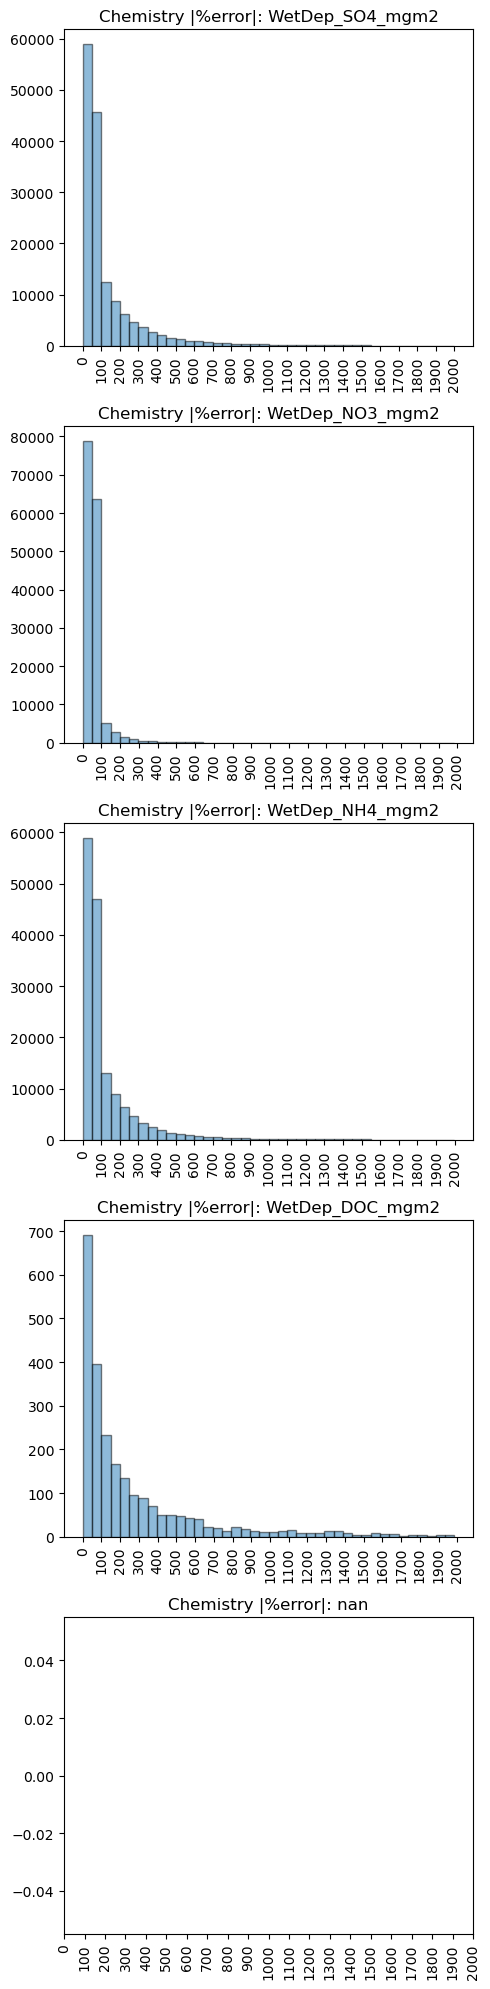

In [19]:
# PLOT: histogram of % error

# Filter the data
mod_nadp_clean_test = mod_nadp_clean_400.loc[((mod_nadp_clean_400['Percent_Error'] < 2000) & (mod_nadp_clean_400['Percent_Error'] > -100)),]
desired_order = ['WetDep_SO4_mgm2', 'WetDep_NO3_mgm2', 'WetDep_NH4_mgm2', 'WetDep_DOC_mgm2']

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_test['Variable'] = pd.Categorical(mod_nadp_clean_test['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_test = mod_nadp_clean_test.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_test['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 5
cols = 1

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(5, 20))
fig.tight_layout(pad=3.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a histogram for each
for idx, variable in enumerate(variables):
    df_touse = mod_nadp_clean_test.loc[mod_nadp_clean_test['Variable'] != 'Precipitation_mm',]
    df = df_touse.loc[df_touse['Variable'] == variable,]
    ax = axs[idx]
    ax.hist(df['Percent_Error'], edgecolor='black', alpha=0.5, bins=40)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'Chemistry |%error|: {variable}')
    ax.set_xticks(np.arange(0, 2001, 100))
    ax.tick_params(axis='x', rotation=90)
    #ax.axvline(x=110, color='red', linestyle=':', linewidth=2.5)
    #ax.axvline(x= 400, color='green', linestyle=':', linewidth=2.5) #line where 90% of data lies

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_test['Variable'].unique()), rows * cols):
    fig.delaxes(axs[idx])

#plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Percent Error Histogram.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
plt.show()

In [20]:
#POST PRECIPITATION FILTERING: 
#Determine the chemistry % error threshold below which 90% of the data is retained.

#Total data counts
total_count_chem = mod_nadp_clean_400.groupby('Variable')['Percent_Error'].count().reset_index()
total_count_chem
total_count_chem['90_perc'] = total_count_chem['Percent_Error']*0.9
total_count_chem = total_count_chem.rename(columns = {'Percent_Error' : 'Total_count'})
total_count_chem

# Define the bins
bins = pd.interval_range(start=0, end=2000, freq=5)
bin_labels = [int(interval.left) for interval in bins]
mod_nadp_clean_400['Error_bin'] = pd.cut(mod_nadp_clean_400['Percent_Error'],bins=bins,labels=bin_labels,include_lowest=True)

# Replace NaN values with a placeholder (-1)
mod_nadp_clean_400['Error_bin_simple'] = mod_nadp_clean_400['Error_bin'].cat.codes
mod_nadp_clean_400['Error_bin_simple'] = mod_nadp_clean_400['Error_bin_simple'].replace(-1, -1).astype(int)

#Group by variable and simple error bin and count
variable_bin_count = mod_nadp_clean_400.groupby(['Variable', 'Error_bin'])['Percent_Error'].count().reset_index()
variable_bin_count = variable_bin_count.rename(columns = {'Percent_Error' : 'Bin_count'})
all_count = pd.merge(variable_bin_count, total_count_chem, on = 'Variable', how = 'left')
all_count.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Bin Chem Percent Error Count.csv')

/glade/derecho/scratch/demurray/tmp/ipykernel_17229/3602585657.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_400['Error_bin'] = pd.cut(mod_nadp_clean_400['Percent_Error'],bins=bins,labels=bin_labels,include_lowest=True)
/glade/derecho/scratch/demurray/tmp/ipykernel_17229/3602585657.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_400['Error_bin_simple'] = mod_nadp_clean_400['Error_bin'].cat.codes
/glade/derecho/scratch/demurray/tmp/ipykernel_17229/3602585657.py:18: S

In [21]:
#Print some statistics on how each of these dataframes compare to one another (excluding DOC because considerably less data here)
#no_filter = mod_nadp_clean.loc[mod_nadp_clean['Variable'] != 'WetDep_DOC_mgm2',]
rain_filter = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == 'WetDep_DOC_mgm2',]

#run_statistics(no_filter, "mod_nadp_clean")
run_statistics(rain_filter, "mod_nadp_clean_400")


Unique site count for mod_nadp_clean_400:
 Variable
Precipitation_mm     0
WetDep_SO4_mgm2      0
WetDep_NO3_mgm2      0
WetDep_NH4_mgm2      0
WetDep_DOC_mgm2     22
Name: siteId, dtype: int64

Observation count for mod_nadp_clean_400:
 Variable
Precipitation_mm       0
WetDep_SO4_mgm2        0
WetDep_NO3_mgm2        0
WetDep_NH4_mgm2        0
WetDep_DOC_mgm2     2460
Name: Modelled, dtype: int64

Average number of observations per site for mod_nadp_clean_400:
 22.363636363636363


/glade/derecho/scratch/demurray/tmp/ipykernel_17229/2092240319.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_400['Month'] = mod_nadp_clean_400['dateOffround'].dt.month
/glade/derecho/scratch/demurray/tmp/ipykernel_17229/2092240319.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_400['Variable'] = pd.Categorical(mod_nadp_clean_400['Variable'], categories=desired_order, ordered=True)


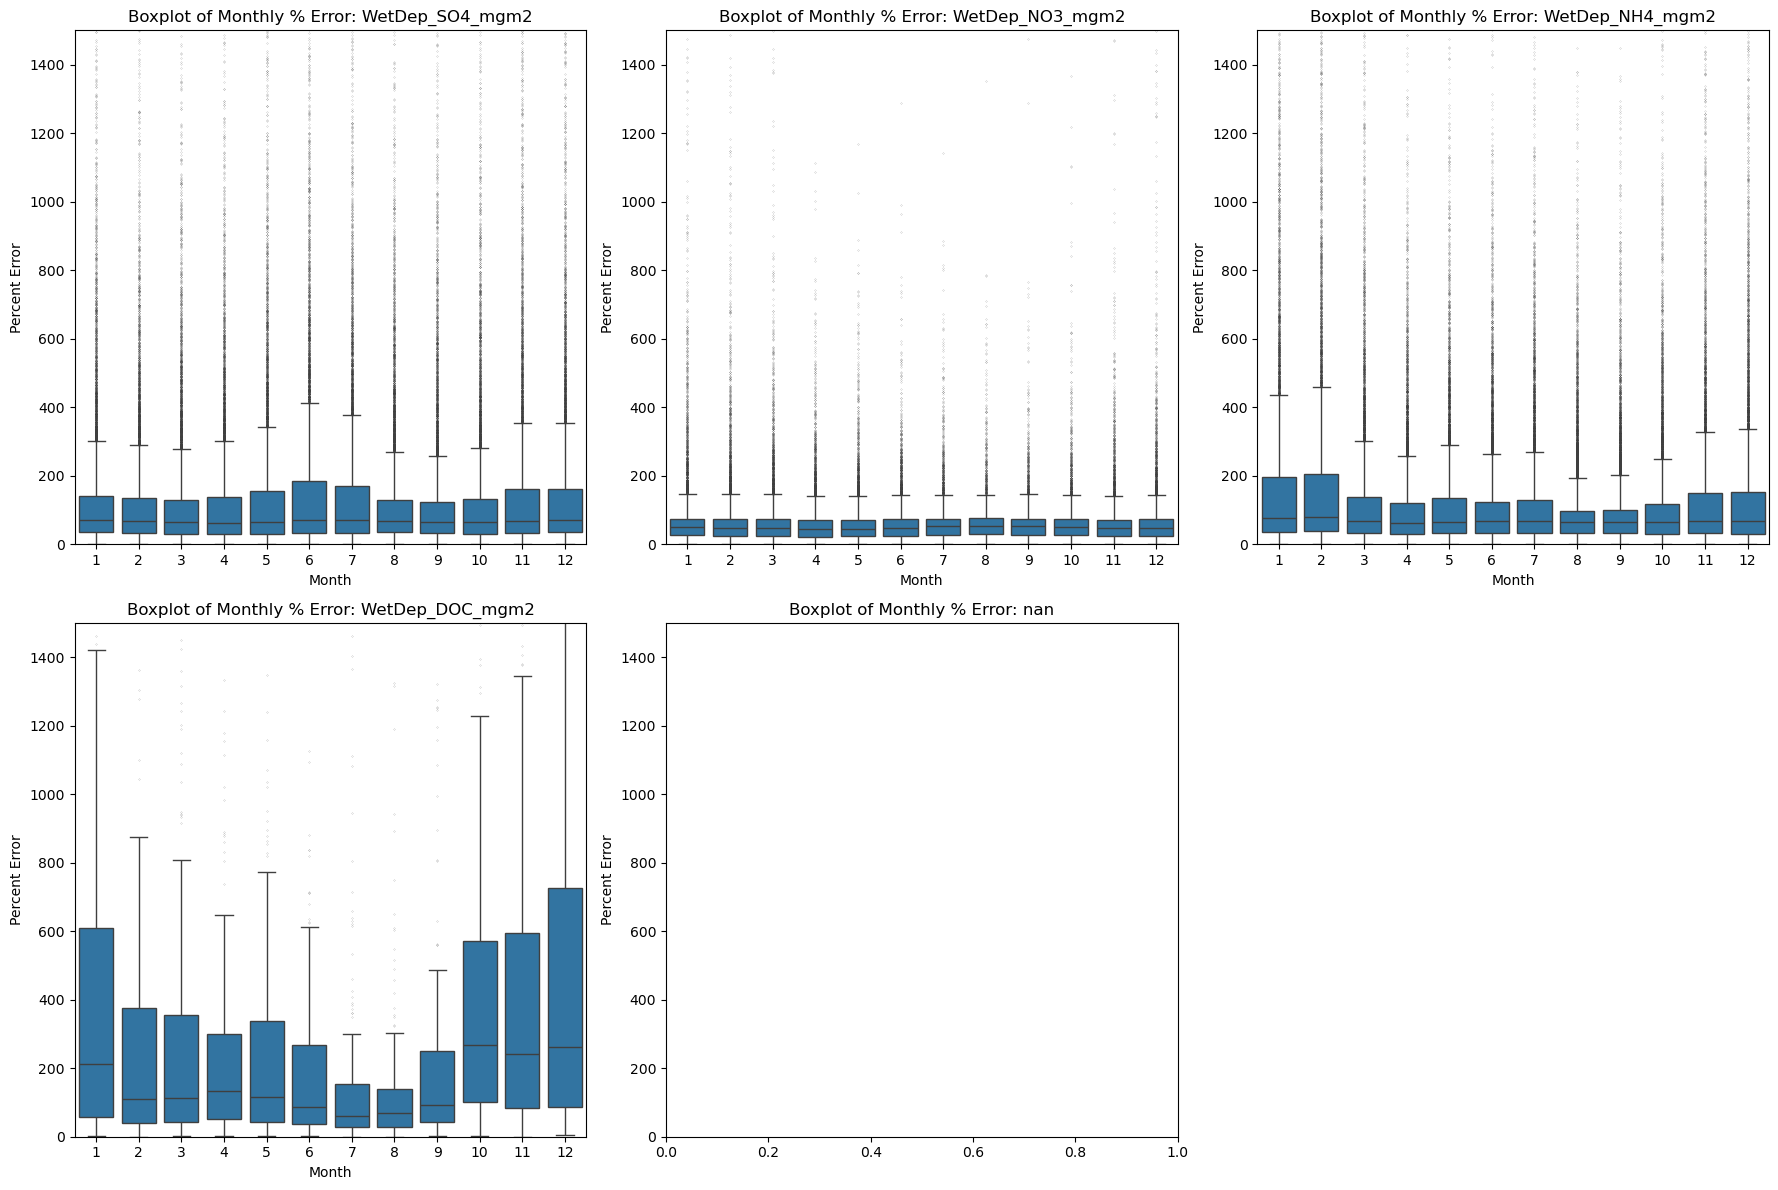

In [22]:
#Plot seasonality of percent error (precip filter)
mod_nadp_clean_400['Month'] = mod_nadp_clean_400['dateOffround'].dt.month

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_400['Variable'] = pd.Categorical(mod_nadp_clean_400['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_400= mod_nadp_clean_400.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_400['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 2
cols = 3

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
fig.tight_layout(pad=5.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a boxplot for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean_400.loc[mod_nadp_clean_400['Variable'] == variable,]
    ax = axs[idx]
    sns.boxplot(data=df, x='Month', y='Percent_Error', ax=ax, fliersize=0.1)
    ax.set_ylabel('Percent Error')
    ax.set_ylim(0, 1500)
    ax.set_title(f'Boxplot of Monthly % Error: {variable}')
   # ax.axhline(y=100, color='red', linestyle=':', linewidth=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(variables), rows * cols):
    fig.delaxes(axs[idx])

plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Precip Filter Seasonal Percent Error Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()

In [23]:
#Plot seasonality of percent error (precip + chem filter)
mod_nadp_clean_100_chem['Month'] = mod_nadp_clean_100_chem['dateOffround'].dt.month

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_100_chem['Variable'] = pd.Categorical(mod_nadp_clean_100_chem['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_100_chem= mod_nadp_clean_100_chem.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_100_chem['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 2
cols = 3

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
fig.tight_layout(pad=5.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a boxplot for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] == variable,]
    ax = axs[idx]
    sns.boxplot(data=df, x='Month', y='Percent_Error', ax=ax, fliersize=0.1)
    ax.set_ylabel('Percent Error')
    ax.set_ylim(-2, 110)
    ax.set_title(f'Boxplot of Monthly % Error: {variable}')
    ax.axhline(y=100, color='red', linestyle=':', linewidth=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(variables), rows * cols):
    fig.delaxes(axs[idx])

plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Chem + Precip Filter Seasonal Percent Error Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()

NameError: name 'mod_nadp_clean_100_chem' is not defined

In [ ]:
#Run a ttest on modeled vs. observed for each variable
warnings.filterwarnings("ignore") # Suppress specific warning types

num_cols = 3
num_rows = 2

# Create the figure and axes for the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20))
axes = axes.flatten()

# Iterate through each unique variable
for idx, i in enumerate(mod_nadp_clean_100_chem['Variable'].unique()):
    # Filter the data for the current variable
    df = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] == i]

    # Melt the DataFrame to long format
    df_long = pd.melt(df, id_vars=['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Precip_Percent_Error', 'Percent_Error', 'Variable'],
                      value_vars=['Modelled', 'Observed'], var_name='Measurement')

    # Perform the t-test
    modelled = df_long[df_long['Measurement'] == 'Modelled']['value'].dropna()
    observed = df_long[df_long['Measurement'] == 'Observed']['value'].dropna()
    t_stat, p_value = ttest_ind(modelled, observed, equal_var=False)  # Using Welch's t-test

    # Calculate the mean difference
    mean_modelled = modelled.mean()
    mean_observed = observed.mean()
    mean_difference = mean_modelled - mean_observed

    # Calculate Cohen's d
    cohens_d = calculate_cohens_d(modelled, observed)
    cohens_d_interpretation = interpret_cohens_d(cohens_d)

    # Plot the barplot
    ax = axes[idx]
    sns.barplot(data=df_long, x='Measurement', y='value', palette='husl', ax=ax)
    ax.set_title(f'Variable: {i}')
    ax.set_ylabel('mg/m2')
    ax.set_xlabel('')
    
    # Add text for the statistics
    stats_text = (f"t-statistic: {t_stat:.3f}\np-value: {p_value:.3f}\n"
                  f"Mean Modelled: {mean_modelled:.3f}\nMean Observed: {mean_observed:.3f}\n"
                  f"Difference: {mean_difference:.3f}\nCohen's d: {cohens_d:.3f} ({cohens_d_interpretation})")
    ax.text(0.5, -0.1, stats_text, ha='center', va='center', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    
    # Adjust layout to avoid overlap
    plt.tight_layout()

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_100_chem['Variable'].unique()), num_rows * num_cols):
    fig.delaxes(axes[idx])

# Show the plot (and optionally save it)
plt.show()

In [ ]:
#Run a regression and scatter plot for observed vs. modelled

# Number of columns and rows for the grid
num_cols = 3
num_rows = 2

# Create the figure and axes for the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20))
axes = axes.flatten()

# Iterate through each unique variable
for idx, i in enumerate(mod_nadp_clean_100_chem['Variable'].unique()):
    
    # Filter the data for the current variable
    df = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] == i]
    df_full = mod_nadp_clean.loc[mod_nadp_clean['Variable'] == i]
    
    # Calculate min and max values for axis limits
    min_val = min(df['Modelled'].min(), df['Observed'].min())
    max_val = max(df['Modelled'].max(), df['Observed'].max())

    # Calculate the regression statistics
    slope, intercept, r_value, p_value, std_err = linregress(df['Modelled'], df['Observed'])

    # Calculate total number of observations and mean per site
    total_observations = len(df)
    mean_per_site = df.groupby('siteId').size().mean()

    # Perform the t-test
    # Melt the DataFrame to long format
    df_long = pd.melt(df, id_vars=['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Precip_Percent_Error', 'Percent_Error', 'Variable'],
                      value_vars=['Modelled', 'Observed'], var_name='Measurement')

    modelled = df_long[df_long['Measurement'] == 'Modelled']['value'].dropna()
    observed = df_long[df_long['Measurement'] == 'Observed']['value'].dropna()
    t_stat, p_value = ttest_ind(modelled, observed, equal_var=False)  # Using Welch's t-test

    # Calculate the mean difference
    mean_modelled = modelled.mean()
    mean_observed = observed.mean()
    mean_difference = mean_modelled - mean_observed

    # Calculate Cohen's d
    cohens_d = calculate_cohens_d(modelled, observed)
    cohens_d_interpretation = interpret_cohens_d(cohens_d)

    # Plot scatter plot
    ax = axes[idx]
    
    # Plot points from the full dataset in very transparent grey
    ax.scatter(df_full['Modelled'], df_full['Observed'], color='grey', alpha=0.05, label='All data')

    #Plot cleaned data
    ax.scatter(df['Modelled'], df['Observed'], alpha=0.3, label = 'Clean data')
    ax.set_title(f'{i}: Modelled vs Observed')
    ax.set_xlabel('Modelled')
    ax.set_ylabel('Observed')
    ax.set_xlim(min_val, max_val)  # Set the same limits for x-axis and y-axis
    ax.set_ylim(min_val, max_val)
    ax.legend(loc = 'upper right')
    
    # Plotting the linear regression line
    ax.plot(df['Modelled'], slope * df['Modelled'] + intercept, color='black')

    # Add the regression equation, R-squared value, and p-value to the plot
    equation = f'y = {slope:.2f}x + {intercept:.2f}'
    r_squared = f'R-squared = {r_value**2:.2f}'
    p_val = f'p-value = {p_value:.2e}'
    stats_text = (f'Total clean values: {total_observations}\n'
                  f'{equation}\n{r_squared}\n'
                  #f"t-statistic: {t_stat:.3f}\np-value: {p_value:.3f}\n"
                  f"Mean Modelled: {mean_modelled:.3f}\nMean Observed: {mean_observed:.3f}\n"
                  f"Difference: {mean_difference:.3f}\nCohen's d: {cohens_d:.3f} ({cohens_d_interpretation})")
    ax.text(0.95, 0.05, stats_text, ha='right', va='bottom', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

    # Add identity line (y=x)
    abline(1, 0, ax=ax, linestyle='--', color='red')

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_100_chem['Variable'].unique()), num_rows * num_cols):
    fig.delaxes(axes[idx])

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot (and optionally save it)
plt.show()